# Dark-matter quantum-sensor response analysis

Forward + inverse analysis of the detector response, organised **by detector**
and, within each, **by velocity-distribution model**. Same pipeline throughout
(load Mathematica response matrix -> forward model `exposure * M @ eta` ->
recover the monotone non-negative flux `x(v_min)`); only two things change:

- **detector** (`material`): **TES (Al)** -- Mermin, 0.1 eV threshold, fine `R10`;
  **MKID (TiN)** -- Lindhard, 0.2 eV threshold, fine `R9`.
- **velocity model**: **Halo** -- standard halo (SHM, `v0=238, ve=250, vesc=544`
  km/s); **pure dark disk** -- same DM density, colder (`v0=70, ve=100,
  vesc=694`). The actual **best-fit uses a mixture** `eta = (1-p)*Halo + p*Disk`
  with disk fraction `p`; because both components carry the same local DM
  density, the mixture's density equals 100% SHM for any `p`. A third model,
  **Bound** (Earth-captured thermal DM), is a separate dense population
  (`rho_b`, isotropic, `vesc=11.2` km/s) -- only the heaviest mass (1 GeV) has
  any signal, since the bound DM is too slow to reach higher `v_min`.

The mixture sections sweep `p` over `DISK_FRACTIONS` and overlay, on each fit,
the **100% SHM** halo and the **`p` x pure disk** component for reference.


In [36]:
%matplotlib inline
import matplotlib.pyplot as plt
from quantum_sensor import DarkMatterQuantumAnalysis, RunConfig

MASS_LABELS = {'1': '10 MeV', '2': '100 MeV', '3': '1 GeV'}
DETECTOR = {'Al': 'TES', 'TiN': 'MKID'}
# Dark-disk mixing fractions p for the best-fit eta = (1-p)*Halo + p*Disk.
DISK_FRACTIONS = (0.05, 0.25)


def run_masses(material, q='0', nbins=5, eta='Halo', background='none',
               disk_fraction=None, masses=('1', '2', '3'), solver='osqp', save=True):
    """Run the forward+inverse analysis for several DM masses.

    Shows one combined figure (the masses side by side). When ``save=True``
    (default) each run is ALSO saved on its own -- flux.csv plus an individual
    flux.pdf -- into its per-run folder
    results/<DET>/bkg-<background>/<material>_q<q>_M<mass>_R<nbins>_<eta>/, so
    every type is stored separately regardless of the combined display.
    """
    fig, axes = plt.subplots(1, len(masses), figsize=(6 * len(masses), 5), squeeze=False)
    for ax, mass in zip(axes[0], masses):
        a = DarkMatterQuantumAnalysis(
            RunConfig(material=material, q=q, mass=mass, nbins=nbins,
                      eta=eta, disk_fraction=disk_fraction, background=background))
        flux = a.optimize(solver=solver)

        if save:
            a.save_flux()                     # flux.csv in this run's own folder
            sfig, sax = plt.subplots(figsize=(8, 6))
            a.plot(save=True, ax=sax)         # individual flux.pdf next to the CSV
            plt.close(sfig)                   # keep only the combined figure on screen

        a.plot(save=False, ax=ax)             # combined panel (display only)
        ax.set_title(f'{material} ({DETECTOR[material]}), $m_\\chi$ = {MASS_LABELS[mass]}',
                     fontsize=13)
        print(f'{material} q{q} M{mass} R{nbins}: {a.n_ebins} E-bins x '
              f'{a.n_vmin} v_min bins, peak flux {flux.max():.2e}')
    model = eta if disk_fraction is None else f'mix {round(disk_fraction*100)}% disk'
    fig.suptitle(f'{material} ({DETECTOR[material]}), q{q}, R{nbins}, {model}, bkg={background}',
                 fontsize=14)
    plt.tight_layout(); plt.show()


# TES (Al)

## Halo (SHM) — reference

### Heavy mediator (q0), 5 energy bins

saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R5_Halo/flux.pdf
Al q0 M1 R5: 5 E-bins x 126 v_min bins, peak flux 7.83e-31
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R5_Halo/flux.pdf
Al q0 M2 R5: 5 E-bins x 59 v_min bins, peak flux 8.26e-32
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_Halo/flux.pdf
Al q0 M3 R5: 5 E-bins x 59 v_min bins, peak flux 8.28e-33


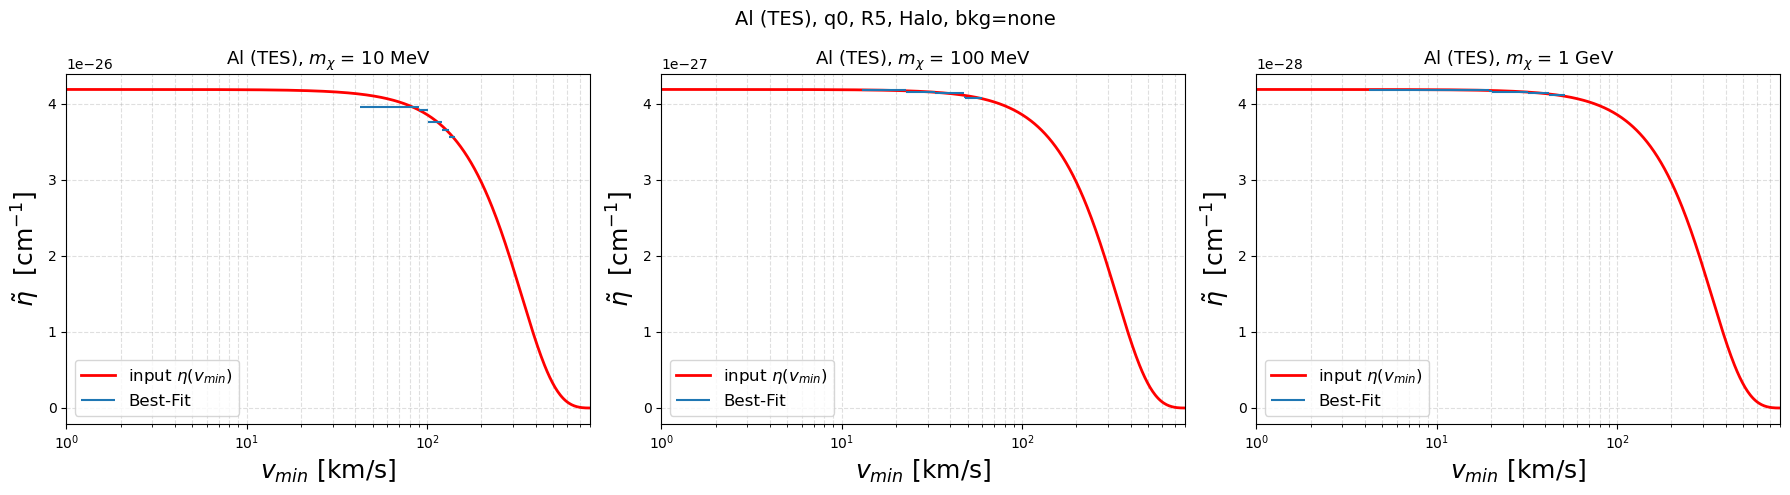

In [37]:
run_masses('Al', q='0', nbins=5, eta='Halo')

### Light mediator (q2), 5 energy bins

saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R5_Halo/flux.pdf
Al q2 M1 R5: 5 E-bins x 174 v_min bins, peak flux 8.01e-31
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R5_Halo/flux.pdf
Al q2 M2 R5: 5 E-bins x 176 v_min bins, peak flux 8.24e-32
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_Halo/flux.pdf
Al q2 M3 R5: 5 E-bins x 183 v_min bins, peak flux 8.26e-33


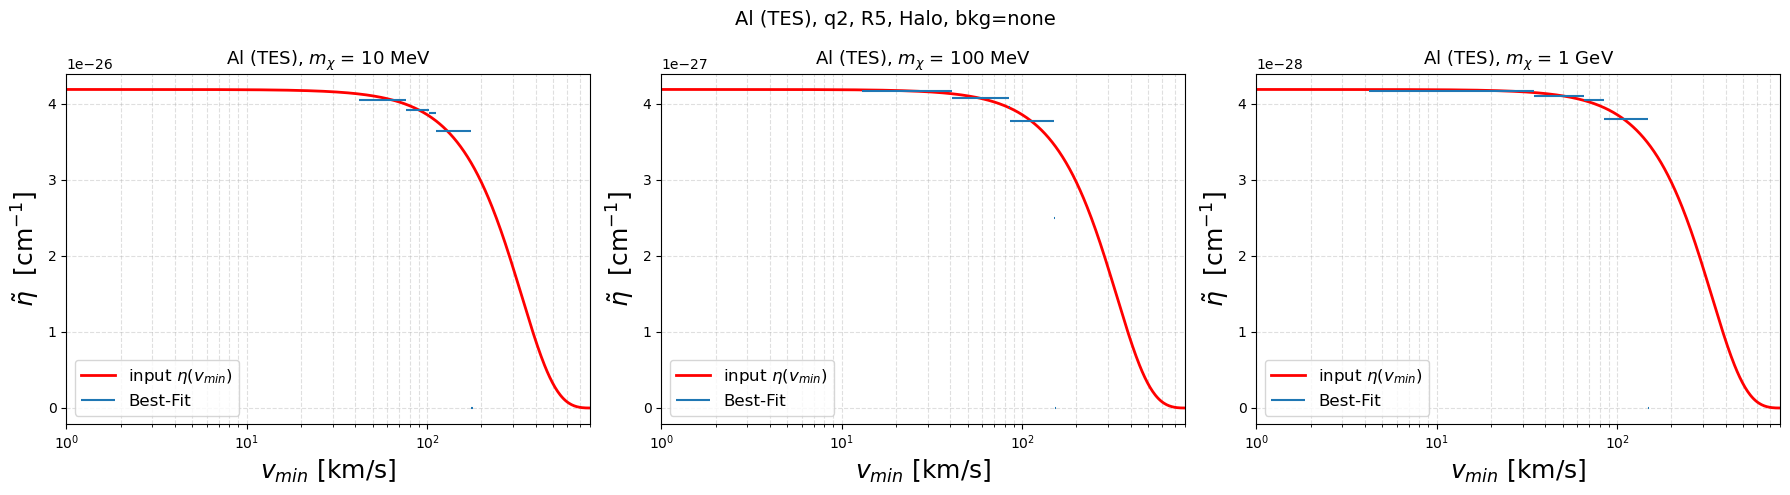

In [38]:
run_masses('Al', q='2', nbins=5, eta='Halo')

### Finer energy binning (R10)

saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R10_Halo/flux.pdf
Al q0 M1 R10: 10 E-bins x 129 v_min bins, peak flux 7.94e-31
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R10_Halo/flux.pdf
Al q0 M2 R10: 10 E-bins x 62 v_min bins, peak flux 8.27e-32
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R10_Halo/flux.pdf
Al q0 M3 R10: 10 E-bins x 62 v_min bins, peak flux 8.29e-33


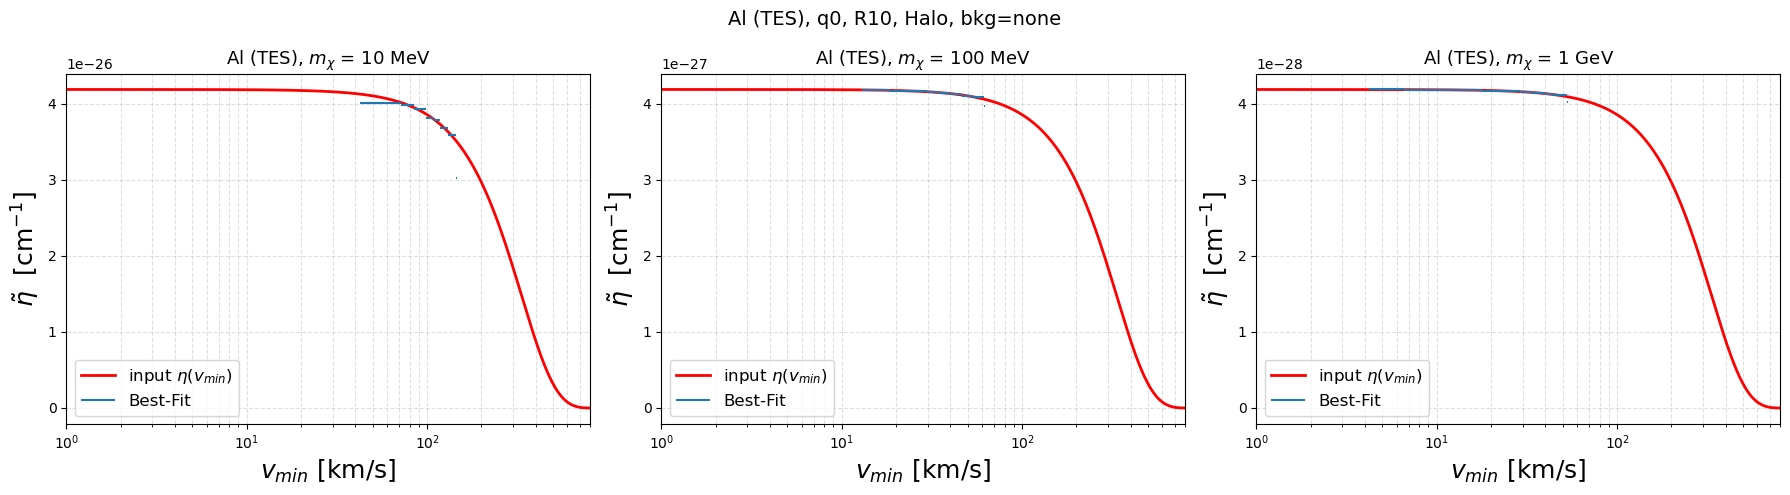

In [39]:
run_masses('Al', q='0', nbins=10, eta='Halo')

## Mixture (best-fit) — sweep dark-disk fraction

`eta = (1-p)*Halo + p*Disk`. Each figure overlays 100% SHM (gray) and `p` x pure disk (green).

### Heavy mediator (q0), 5 energy bins

saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R5_mix5/flux.pdf
Al q0 M1 R5: 5 E-bins x 126 v_min bins, peak flux 8.21e-31
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R5_mix5/flux.pdf
Al q0 M2 R5: 5 E-bins x 59 v_min bins, peak flux 8.97e-32
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_mix5/flux.pdf
Al q0 M3 R5: 5 E-bins x 59 v_min bins, peak flux 9.00e-33


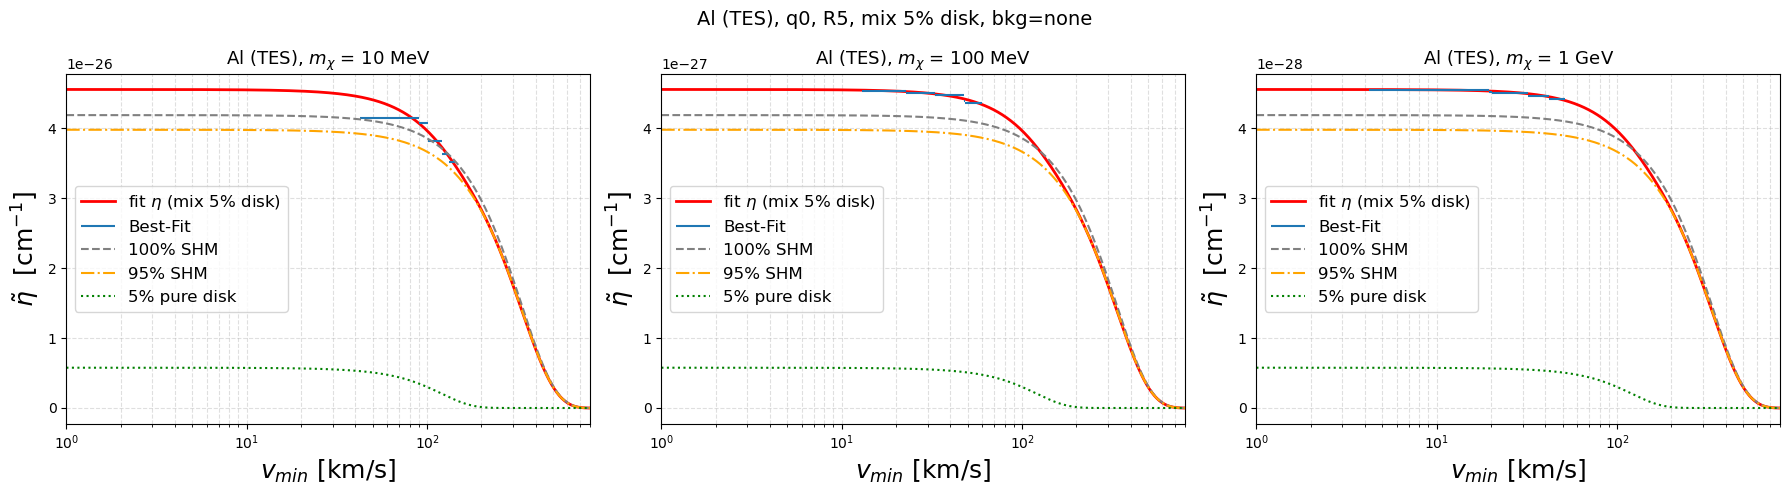

saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R5_mix25/flux.pdf
Al q0 M1 R5: 5 E-bins x 126 v_min bins, peak flux 9.72e-31
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R5_mix25/flux.pdf
Al q0 M2 R5: 5 E-bins x 59 v_min bins, peak flux 1.18e-31
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_mix25/flux.pdf
Al q0 M3 R5: 5 E-bins x 59 v_min bins, peak flux 1.19e-32


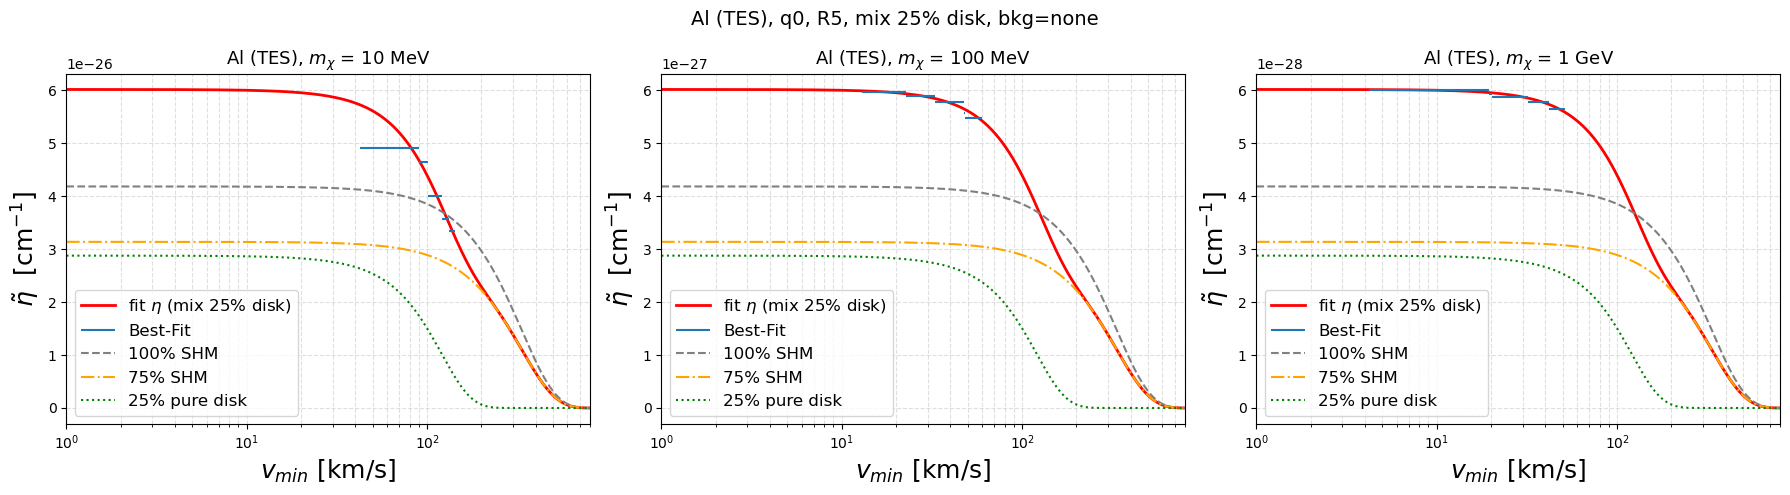

In [40]:
for p in DISK_FRACTIONS:
    run_masses('Al', q='0', nbins=5, disk_fraction=p)

### Light mediator (q2), 5 energy bins

saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R5_mix5/flux.pdf
Al q2 M1 R5: 5 E-bins x 174 v_min bins, peak flux 8.51e-31
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R5_mix5/flux.pdf
Al q2 M2 R5: 5 E-bins x 176 v_min bins, peak flux 8.93e-32
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_mix5/flux.pdf
Al q2 M3 R5: 5 E-bins x 183 v_min bins, peak flux 8.97e-33


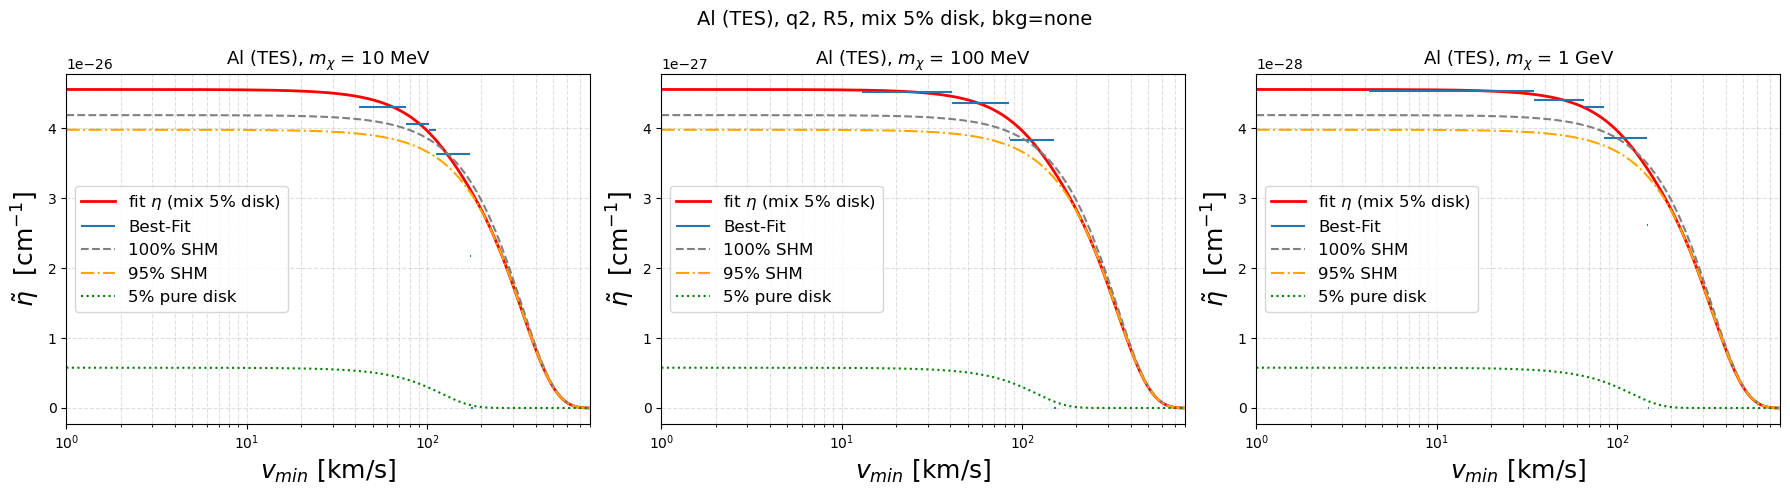

saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R5_mix25/flux.pdf
Al q2 M1 R5: 5 E-bins x 174 v_min bins, peak flux 1.05e-30
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R5_mix25/flux.pdf
Al q2 M2 R5: 5 E-bins x 176 v_min bins, peak flux 1.17e-31
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_mix25/flux.pdf
Al q2 M3 R5: 5 E-bins x 183 v_min bins, peak flux 1.18e-32


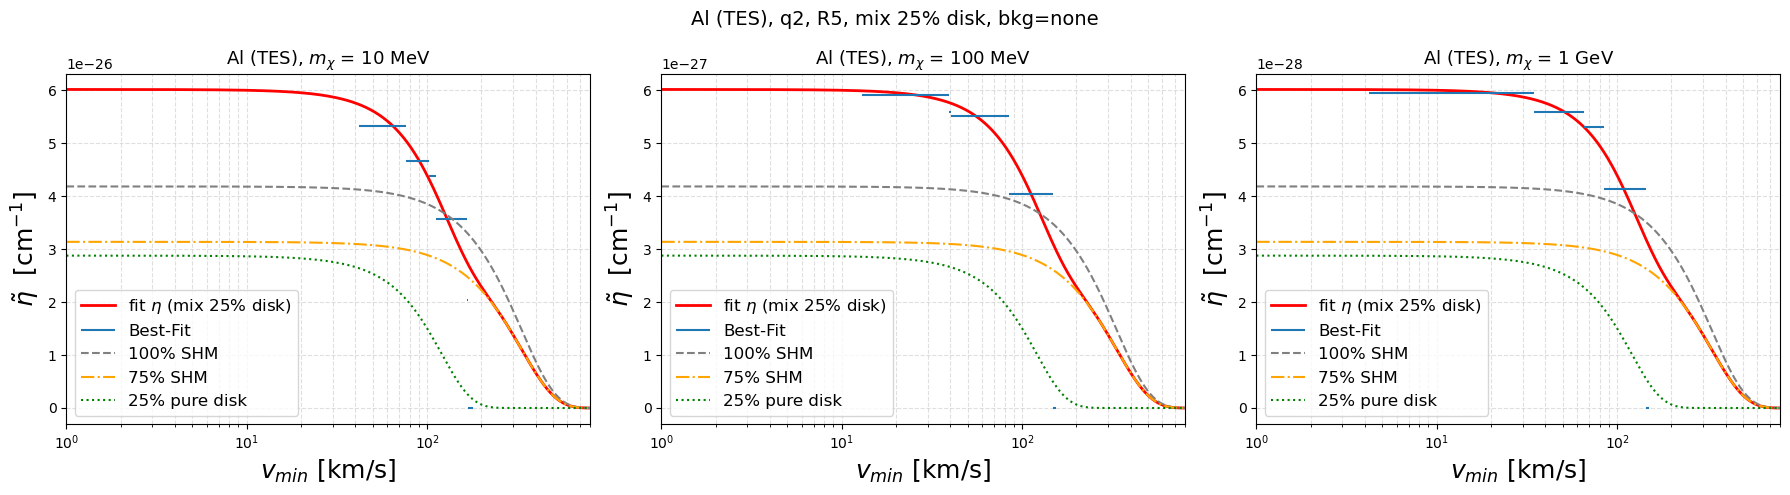

In [41]:
for p in DISK_FRACTIONS:
    run_masses('Al', q='2', nbins=5, disk_fraction=p)

## Bound (Earth-bound thermal DM)

Dense (`rho_b = 1e14` GeV/cm^3), isotropic, cold (`v0 ~ 2.16` km/s at 1 GeV), `vesc = 11.2` km/s. Only **M3 (1 GeV)** is shown: the bound population is too slow to reach the `v_min` thresholds of the lighter masses (M1/M2 have no signal).

saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_Bound/flux.pdf
Al q0 M3 R5: 5 E-bins x 59 v_min bins, peak flux 6.30e-19


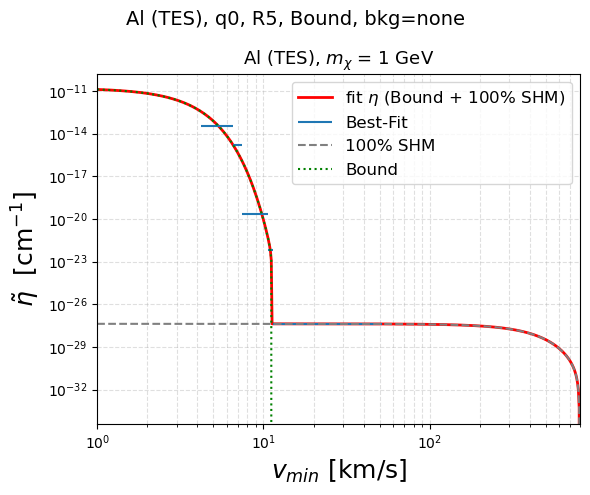

In [42]:
run_masses('Al', q='0', nbins=5, eta='Bound', masses=('3',))

saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R10_Bound/flux.pdf
Al q0 M3 R10: 10 E-bins x 62 v_min bins, peak flux 1.39e-18


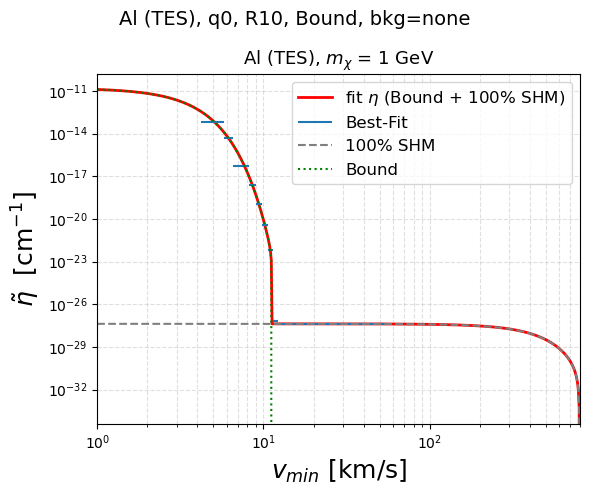

In [43]:
run_masses('Al', q='0', nbins=10, eta='Bound', masses=('3',))

## With a background scenario (Halo)

signal     : [0.11750272 0.24435997 0.34638123 0.47692563 0.57408796]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]


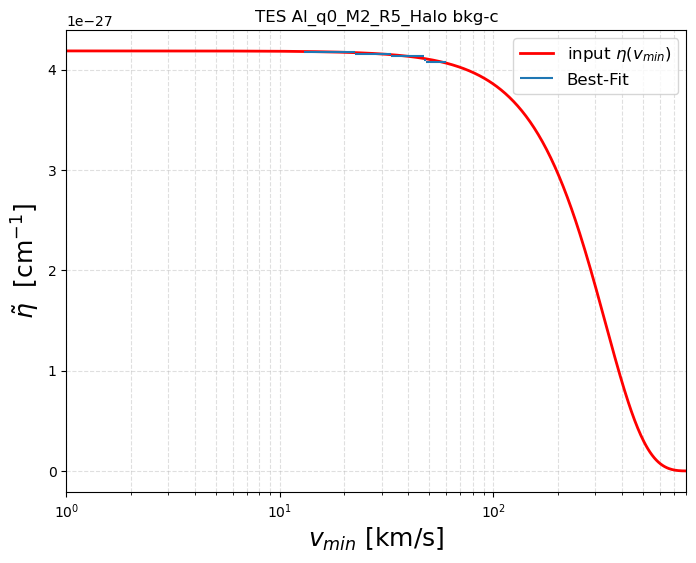

In [44]:
a = DarkMatterQuantumAnalysis(
    RunConfig(material='Al', q='0', mass='2', nbins=5, eta='Halo', background='c'))
a.optimize(solver='osqp')
print('signal     :', a.signal)
print('background :', a.background)
a.plot(save=False); plt.show()

# MKID (TiN)

Titanium-nitride detector, Lindhard dielectric. Threshold **0.2 eV** (bins start at 0.2 eV, fine binning **`R9`**). Heavy mediator (`q0`) only so far.

## Halo (SHM) — reference

### Heavy mediator (q0), 5 energy bins

saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R5_Halo/flux.pdf
TiN q0 M1 R5: 5 E-bins x 110 v_min bins, peak flux 7.97e-31
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R5_Halo/flux.pdf
TiN q0 M2 R5: 5 E-bins x 101 v_min bins, peak flux 8.24e-32
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_Halo/flux.pdf
TiN q0 M3 R5: 5 E-bins x 111 v_min bins, peak flux 8.26e-33


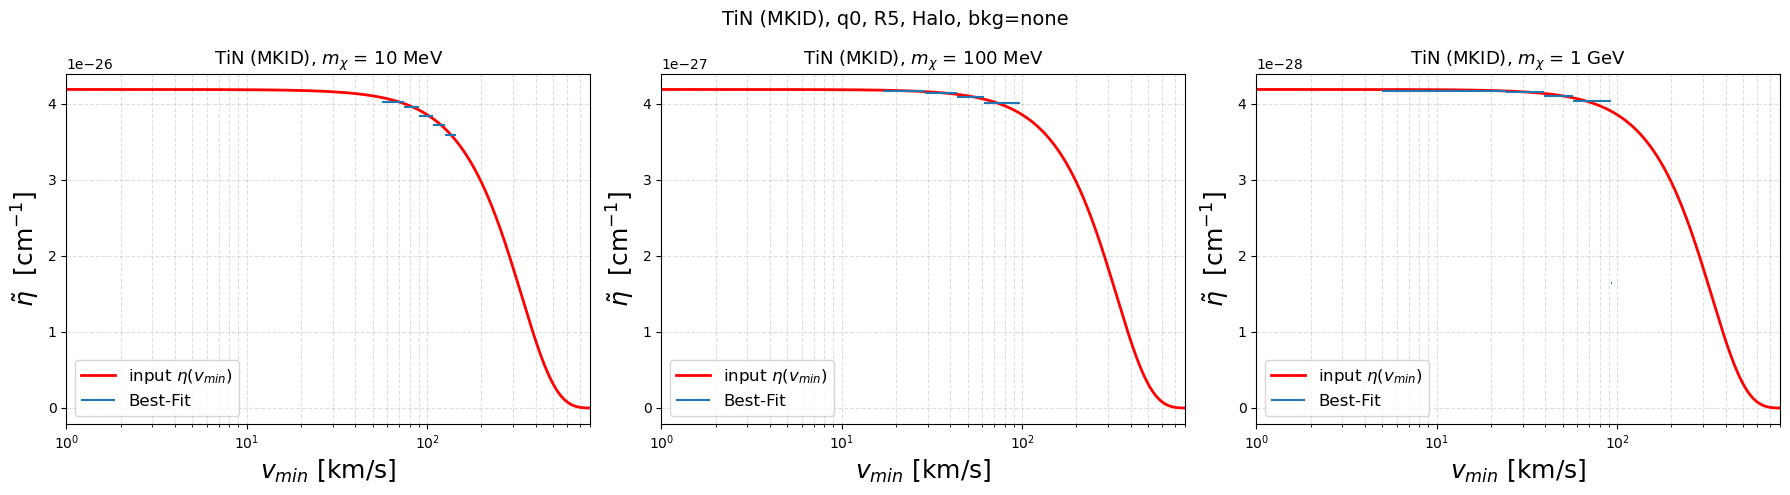

In [45]:
run_masses('TiN', q='0', nbins=5, eta='Halo')

### Finer energy binning (R9)

saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R9_Halo/flux.pdf
TiN q0 M1 R9: 9 E-bins x 115 v_min bins, peak flux 7.97e-31
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R9_Halo/flux.pdf
TiN q0 M2 R9: 9 E-bins x 106 v_min bins, peak flux 8.24e-32
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R9_Halo/flux.pdf
TiN q0 M3 R9: 9 E-bins x 116 v_min bins, peak flux 8.26e-33


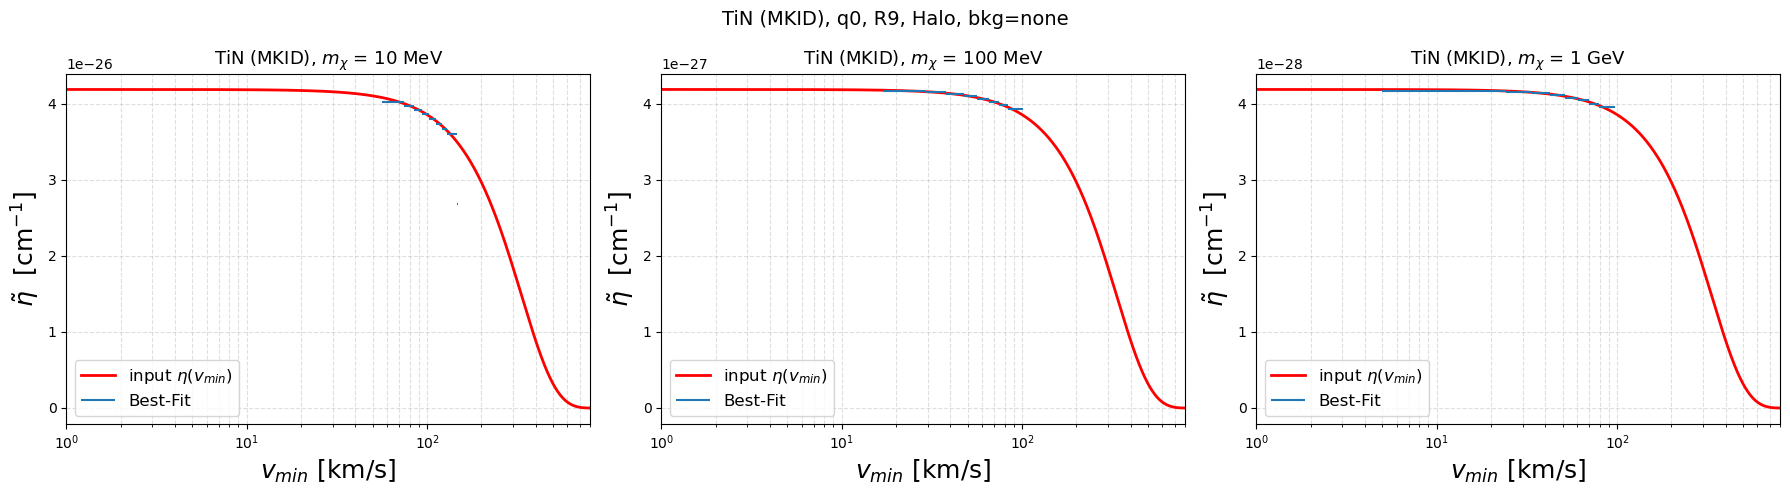

In [46]:
run_masses('TiN', q='0', nbins=9, eta='Halo')

## Mixture (best-fit) — sweep dark-disk fraction

`eta = (1-p)*Halo + p*Disk`. Each figure overlays 100% SHM (gray) and `p` x pure disk (green).

### Heavy mediator (q0), 5 energy bins

saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R5_mix5/flux.pdf
TiN q0 M1 R5: 5 E-bins x 110 v_min bins, peak flux 8.44e-31
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R5_mix5/flux.pdf
TiN q0 M2 R5: 5 E-bins x 101 v_min bins, peak flux 8.94e-32
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_mix5/flux.pdf
TiN q0 M3 R5: 5 E-bins x 111 v_min bins, peak flux 8.97e-33


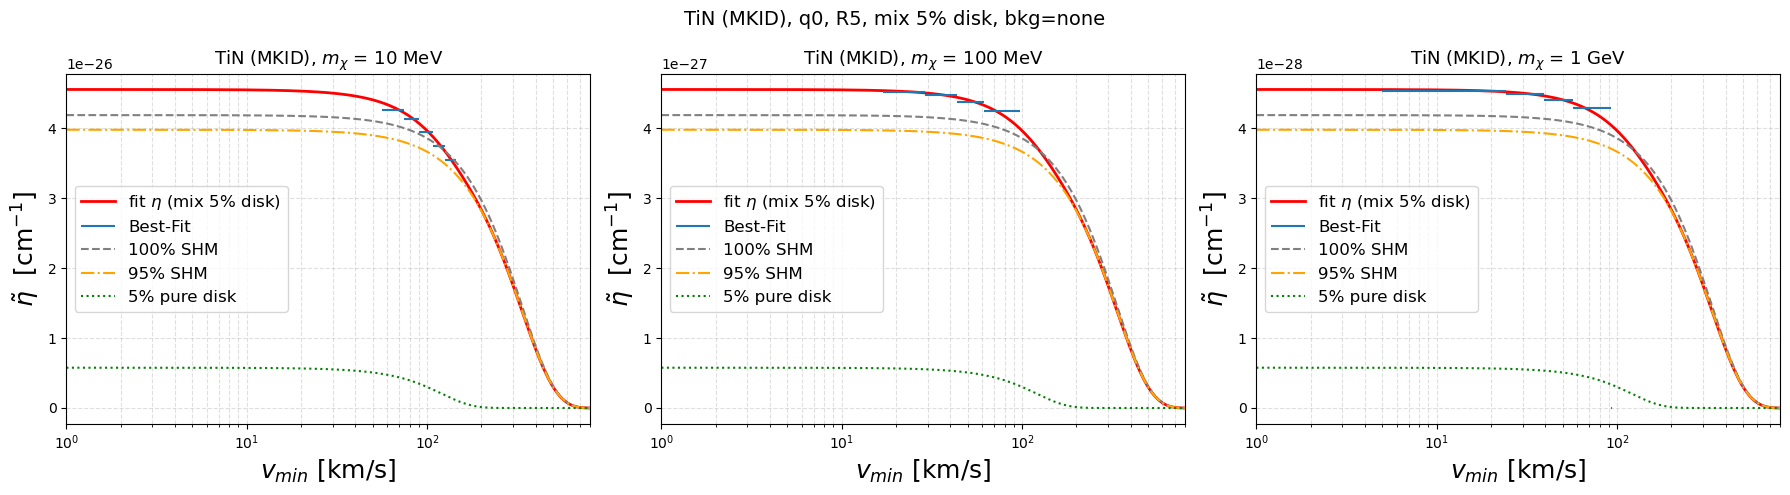

saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R5_mix25/flux.pdf
TiN q0 M1 R5: 5 E-bins x 110 v_min bins, peak flux 1.03e-30
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R5_mix25/flux.pdf
TiN q0 M2 R5: 5 E-bins x 101 v_min bins, peak flux 1.17e-31
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_mix25/flux.pdf
TiN q0 M3 R5: 5 E-bins x 111 v_min bins, peak flux 1.18e-32


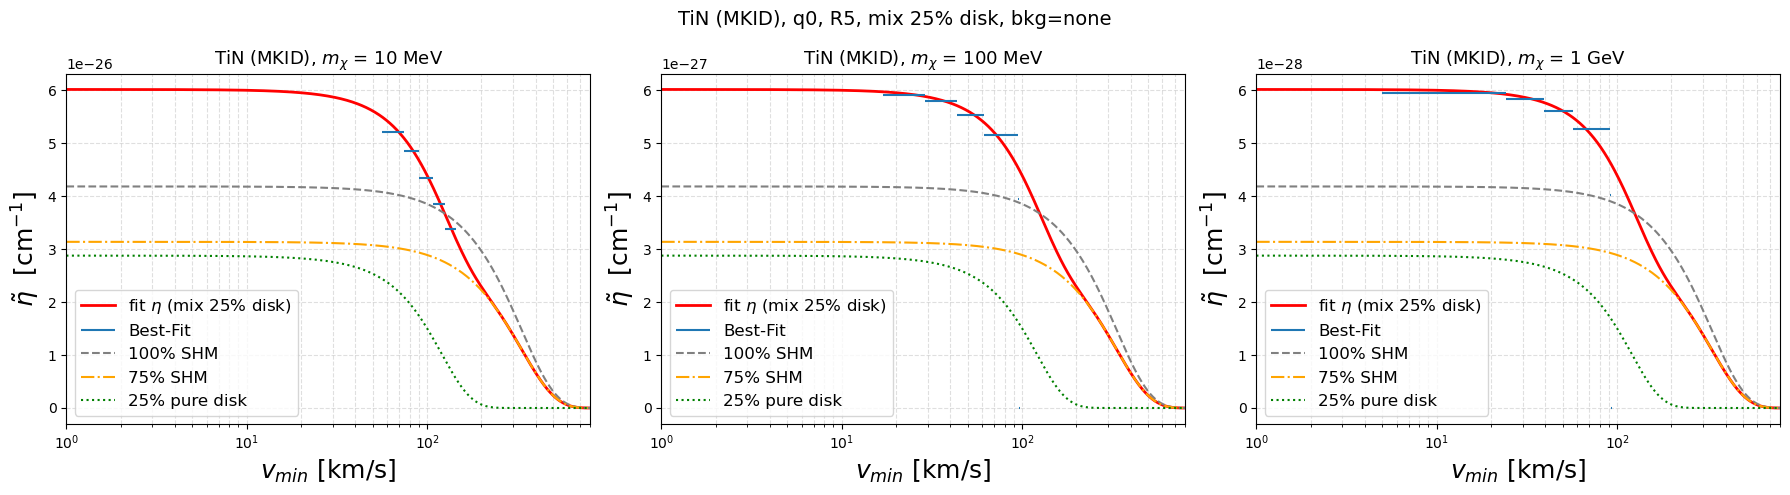

In [47]:
for p in DISK_FRACTIONS:
    run_masses('TiN', q='0', nbins=5, disk_fraction=p)

### Finer energy binning (R9)

saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R9_mix5/flux.pdf
TiN q0 M1 R9: 9 E-bins x 115 v_min bins, peak flux 8.44e-31
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R9_mix5/flux.pdf
TiN q0 M2 R9: 9 E-bins x 106 v_min bins, peak flux 8.94e-32
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R9_mix5/flux.pdf
TiN q0 M3 R9: 9 E-bins x 116 v_min bins, peak flux 8.97e-33


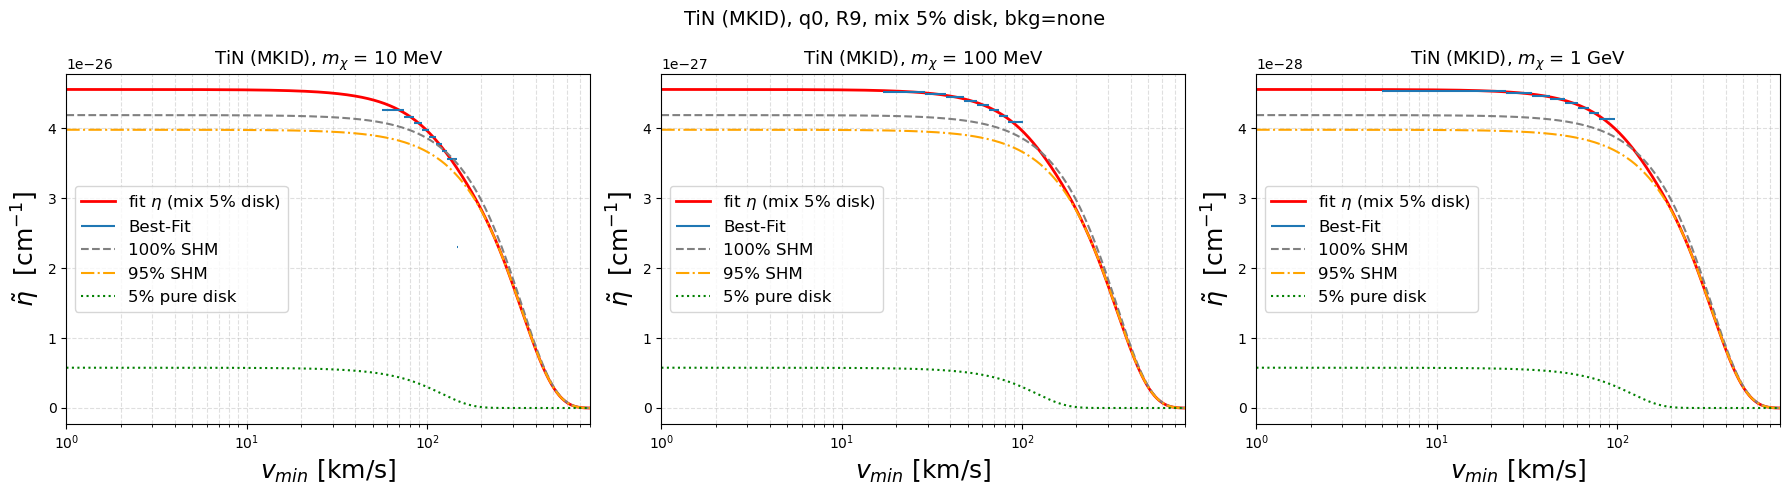

saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R9_mix25/flux.pdf
TiN q0 M1 R9: 9 E-bins x 115 v_min bins, peak flux 1.03e-30
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R9_mix25/flux.pdf
TiN q0 M2 R9: 9 E-bins x 106 v_min bins, peak flux 1.17e-31
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R9_mix25/flux.pdf
TiN q0 M3 R9: 9 E-bins x 116 v_min bins, peak flux 1.18e-32


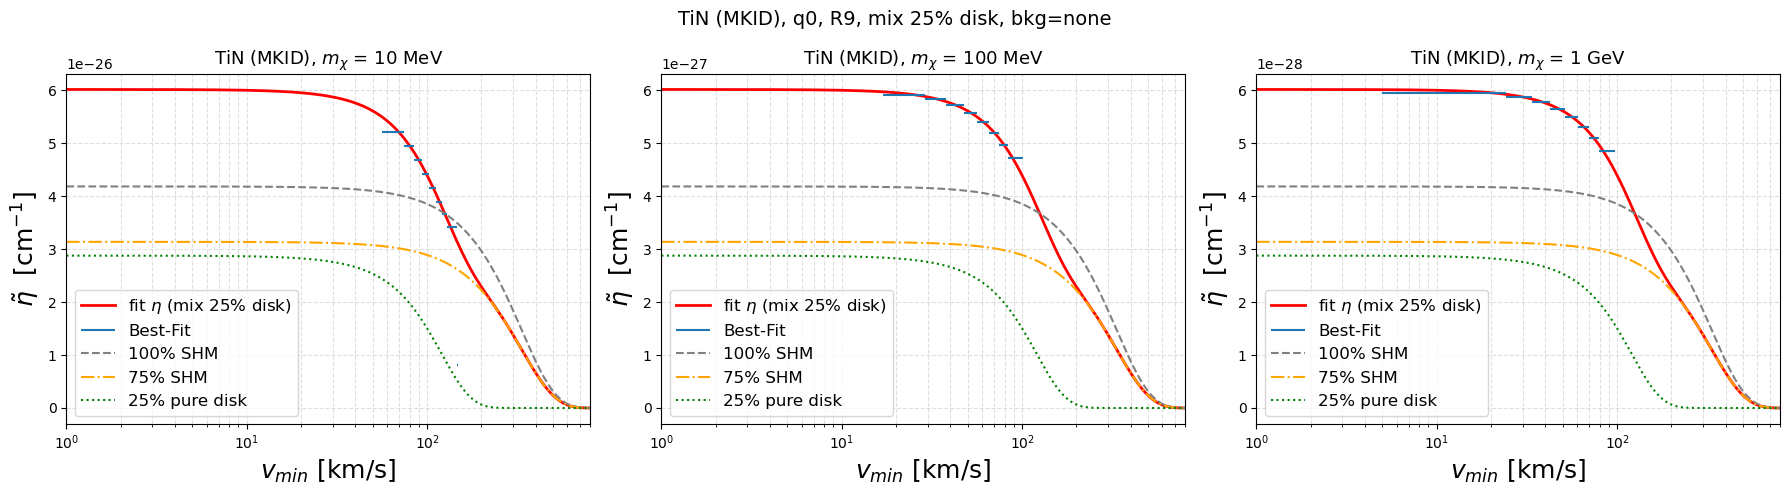

In [48]:
for p in DISK_FRACTIONS:
    run_masses('TiN', q='0', nbins=9, disk_fraction=p)

## Bound (Earth-bound thermal DM)

Dense (`rho_b = 1e14` GeV/cm^3), isotropic, cold (`v0 ~ 2.16` km/s at 1 GeV), `vesc = 11.2` km/s. Only **M3 (1 GeV)** is shown: the bound population is too slow to reach the `v_min` thresholds of the lighter masses (M1/M2 have no signal).

saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_Bound/flux.pdf
TiN q0 M3 R5: 5 E-bins x 111 v_min bins, peak flux 7.63e-20


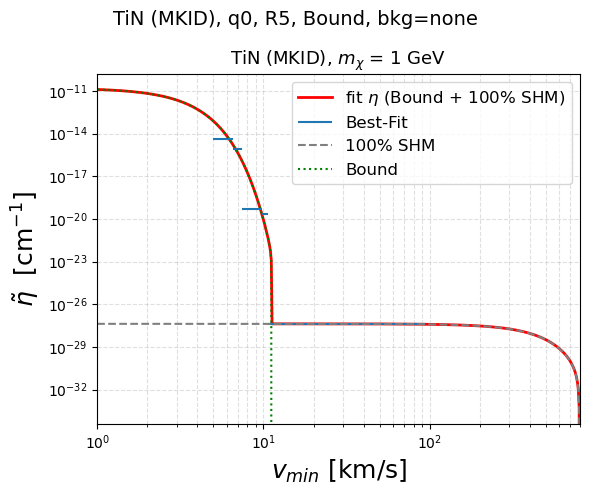

In [49]:
run_masses('TiN', q='0', nbins=5, eta='Bound', masses=('3',))

saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R9_Bound/flux.pdf
TiN q0 M3 R9: 9 E-bins x 116 v_min bins, peak flux 8.14e-20


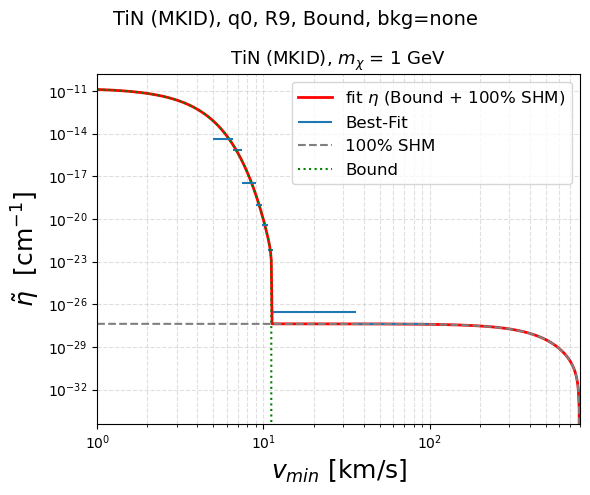

In [50]:
run_masses('TiN', q='0', nbins=9, eta='Bound', masses=('3',))